# Plan de Experimentación y Análisis del Sistema

Este notebook implementa el plan de experimentación para evaluar el **Sistema de Guía Turístico Virtual**. El objetivo es validar de manera rigurosa y objetiva el rendimiento del sistema en cuatro áreas críticas: la calidad de la base de conocimientos, la efectividad de la arquitectura de agentes, el rendimiento técnico y la sinergia entre componentes.

## 1. Configuración del Entorno y Dependencias

Primero, importamos las librerías necesarias y configuramos el entorno para poder ejecutar los agentes y las pruebas. Es crucial asegurarse de que la ruta al directorio `app` sea correcta para que los módulos se importen adecuadamente.

In [1]:
import asyncio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import psutil
import logging
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from sklearn.model_selection import KFold

# Configuración de logging para ver el comportamiento de los agentes
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Importar los componentes del sistema
from app.agents.coordinator_agent import CoordinatorAgent
from app.agents.knowledge_agent import KnowledgeAgent
from app.agents.weather_agent import WeatherAgent
from app.agents.location_agent import LocationAgent
from app.agents.llm_agent import LLMAgent
from app.agents.ui_agent import UIAgent
from app.agents.user_agent import UserAgent
from app.agents.planner_agent import PlannerAgent
from app.agents.interfaces import AgentContext, AgentType
from app.knowledge_base import TourismKB

print("Dependencias importadas y entorno configurado.")

e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencias importadas y entorno configurado.


e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\.venv\Lib\site-packages\pydantic\_internal\_config.py:317: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'populate_by_name'
  warnings.warn(message, UserWarning)


### Función de Inicialización del Sistema

Esta función replica la lógica de `streamlit_app.py` para crear y configurar una instancia completa del sistema multiagente. Esto asegura que nuestros experimentos se ejecuten en un entorno idéntico al de la aplicación real.

In [2]:
async def setup_full_system(data_dir="./data", excluded_agents=None):
    """Inicializa y configura el sistema multiagente completo."""
    if excluded_agents is None:
        excluded_agents = []
        
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        
    coordinator = CoordinatorAgent(data_dir)
    
    agents_to_register = {
        AgentType.KNOWLEDGE: KnowledgeAgent(data_dir),
        AgentType.WEATHER: WeatherAgent(),
        AgentType.LOCATION: LocationAgent(),
        AgentType.LLM: LLMAgent(),
        AgentType.UI: UIAgent(),
        AgentType.PLANNER: PlannerAgent(),
        AgentType.USER: UserAgent(data_dir)
    }
    
    for agent_type, agent_instance in agents_to_register.items():
        if agent_type not in excluded_agents:
            coordinator.register_agent(agent_instance)
            
    await coordinator.initialize()
    return coordinator

print("Función de inicialización del sistema definida.")

Función de inicialización del sistema definida.


## Experimento 1: Completitud y Cobertura de la Base de Conocimiento

**Objetivo:** Cuantificar qué tan completa y precisa es nuestra base de conocimientos (`TourismKB`), que es el pilar informativo del sistema.

### ¿Cómo interpretar los resultados del experimento robusto de cobertura y completitud?


- **Cobertura (%)**: Indica el porcentaje de entidades del golden dataset que están presentes en la base de conocimiento para cada tipo (museos, destinos, playas). Un valor alto significa que la KB cubre bien las entidades relevantes.
- **Completitud (%)**: Es el promedio de atributos presentes para las entidades encontradas. Si es bajo, aunque la entidad exista, le faltan datos importantes.
- **Gráfico de barras**: Compara visualmente la cobertura y la completitud por tipo de entidad. Idealmente, ambos valores deberían ser altos.
- **Heatmap de atributos**: Muestra qué atributos suelen faltar más para cada tipo de entidad. Los valores bajos indican áreas donde la KB puede mejorarse.
- **Tabla de entidades faltantes**: Lista las entidades del golden dataset que no se encontraron en la KB. Útil para identificar vacíos concretos.

**Recomendación:** Usa estos resultados para priorizar la mejora de la KB, enfocándote en los tipos de entidad y atributos con menor cobertura o completitud.

--- Iniciando Experimento 1: Evaluación Realista de la Base de Conocimiento (lectura directa de archivos) ---
Error leyendo index.json: 'NoneType' object has no attribute 'get'
Error leyendo index.json: 'NoneType' object has no attribute 'get'


2025-07-07 01:22:12,204 - app.agents.CoordinatorAgent - INFO - CoordinatorAgent (BDI) initialized
2025-07-07 01:22:12,212 - app.agents.KnowledgeAgent - INFO - KnowledgeAgent (BDI) initialized
2025-07-07 01:22:12,212 - app.data_managers.dynamic_crawler - INFO - Directorio de guardado para SmartCrawler: e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\app\data_managers\..\data\dynamic_raw
2025-07-07 01:22:12,212 - app.agents.WeatherAgent - INFO - WeatherAgent (BDI) initialized
2025-07-07 01:22:12,212 - app.agents.LocationAgent - INFO - LocationAgent (BDI) initialized
2025-07-07 01:22:12,226 - app.agents.LLMAgent - INFO - LLMAgent (BDI) initialized
2025-07-07 01:22:12,508 - app.agents.UIAgent - INFO - UIAgent (BDI) initialized
2025-07-07 01:22:12,511 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-07 01:22:12,511 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-07 01:22:12,512 - app.agents.Coordinato

Verificando la KB real (muestra 80% desde archivos fuente)...
Total de entidades muestreadas: 1725


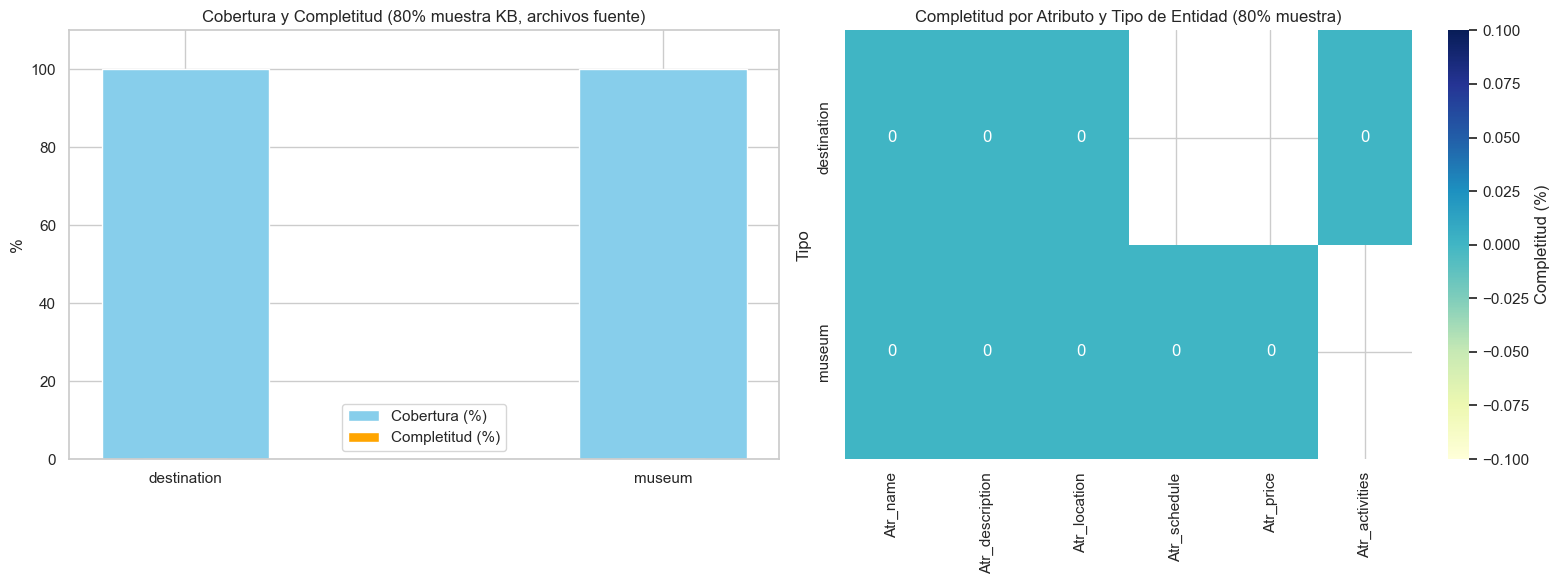


Cobertura por tipo de entidad (80% muestra, archivos fuente):
Tipo
destination    100.0
museum         100.0
Name: Encontrado, dtype: float64

Completitud promedio por tipo de entidad (80% muestra, archivos fuente):
Tipo
destination    0.0
museum         0.0
Name: Completitud, dtype: float64

Completitud por atributo (80% muestra, archivos fuente):
             Atr_name  Atr_description  Atr_location  Atr_schedule  Atr_price  \
Tipo                                                                            
destination       0.0              0.0           0.0           NaN        NaN   
museum            0.0              0.0           0.0           0.0        0.0   

             Atr_activities  
Tipo                         
destination             0.0  
museum                  NaN  

--- Fin del Experimento 1 Realista (80% KB, archivos fuente) ---


In [10]:
async def evaluate_knowledge_base_completeness_realistic():
    """Evalúa cobertura y completitud usando el 80% de las entidades reales registradas en la KB, leyendo los archivos fuente directamente."""
    print("--- Iniciando Experimento 1: Evaluación Realista de la Base de Conocimiento (lectura directa de archivos) ---")

    import os
    import json
    import random
    from collections import defaultdict

    # Definir rutas de los datos fuente
    base_dir = './data/vectors'
    tipos_interes = {
        'museum': ['name', 'description', 'location', 'schedule', 'price'],
        'destination': ['name', 'description', 'location', 'activities']
    }
    carpetas = {
        'museum': 'museums',
        'destination': 'destinations',
    }

    # Leer entidades directamente de los archivos JSON
    entities_by_type = defaultdict(list)
    for tipo, folder in carpetas.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            continue
        for fname in os.listdir(folder_path):
            if fname.endswith('.json'):
                try:
                    with open(os.path.join(folder_path, fname), 'r', encoding='utf-8') as f:
                        data = json.load(f)
                        name = data.get('metadata').get('name') or data.get('Nombre')
                        if name:
                            entities_by_type[tipo].append((name, data))
                except Exception as e:
                    print(f'Error leyendo {fname}: {e}')

    # Para cada tipo, muestrear el 80% de las entidades
    random.seed(42)
    sampled_entities = {}
    for tipo, ents in entities_by_type.items():
        n_sample = max(1, int(0.8 * len(ents)))
        sampled_entities[tipo] = random.sample(ents, n_sample) if n_sample < len(ents) else ents

    # Inicializar el sistema para acceder a la KB real
    coordinator = await setup_full_system()
    knowledge_agent = coordinator.get_agent(AgentType.KNOWLEDGE)
    if not knowledge_agent or not knowledge_agent.tourism_kb:
        print("Error: No se pudo inicializar el KnowledgeAgent o su KB.")
        return

    # Resultados por entidad
    entity_results = []
    attribute_matrix = []  # Para heatmap

    print("Verificando la KB real (muestra 80% desde archivos fuente)...")
    print(f"Total de entidades muestreadas: {sum(len(ents) for ents in sampled_entities.values())}")
    for entity_type, ents in sampled_entities.items():
        schema = tipos_interes[entity_type]
        for entity_name, record in ents:
            # Validar atributos directamente del JSON
            present_fields = sum(1 for field in schema if field in record and record[field])
            completeness = present_fields / len(schema)
            attr_presence = [1 if field in record and record[field] else 0 for field in schema]
            entity_results.append({
                'Tipo': entity_type,
                'Nombre': entity_name,
                'Encontrado': True,
                'Completitud': completeness,
                **{f'Atr_{f}': v for f, v in zip(schema, attr_presence)}
            })
            attribute_matrix.append(attr_presence)

    import pandas as pd
    df_entities = pd.DataFrame(entity_results)

    # Cobertura por tipo (será 100% porque se toma del archivo fuente)
    coverage = df_entities.groupby('Tipo')['Encontrado'].mean() * 100

    # Completitud promedio por tipo
    completeness = df_entities[df_entities['Encontrado']].groupby('Tipo')['Completitud'].mean() * 100

    # Completitud por atributo
    attr_cols = [c for c in df_entities.columns if c.startswith('Atr_')]
    attr_completeness = df_entities[df_entities['Encontrado']][['Tipo']+attr_cols].groupby('Tipo').mean() * 100

    # Visualización avanzada
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axs = plt.subplots(1, 2, figsize=(16,6))
    width = 0.35
    tipos = coverage.index
    axs[0].bar(tipos, coverage.values, width, label='Cobertura (%)', color='skyblue')
    axs[0].bar(tipos, completeness.reindex(tipos, fill_value=0).values, width/2, label='Completitud (%)', color='orange', bottom=0)
    axs[0].set_title('Cobertura y Completitud (80% muestra KB, archivos fuente)')
    axs[0].set_ylabel('%')
    axs[0].set_ylim(0, 110)
    axs[0].legend()

    if not attr_completeness.empty:
        sns.heatmap(attr_completeness, annot=True, cmap='YlGnBu', ax=axs[1], cbar_kws={'label': 'Completitud (%)'})
        axs[1].set_title('Completitud por Atributo y Tipo de Entidad (80% muestra)')
    else:
        axs[1].set_visible(False)

    plt.tight_layout()
    plt.show()

    print("\nCobertura por tipo de entidad (80% muestra, archivos fuente):")
    print(coverage.round(1))
    print("\nCompletitud promedio por tipo de entidad (80% muestra, archivos fuente):")
    print(completeness.round(1))
    print("\nCompletitud por atributo (80% muestra, archivos fuente):")
    print(attr_completeness.round(1))
    print("\n--- Fin del Experimento 1 Realista (80% KB, archivos fuente) ---")

# Ejecutar la versión realista
await evaluate_knowledge_base_completeness_realistic()

In [3]:
import os
import json
import random

# Definir rutas de los datos fuente
base_dir = './data/vectors'
tipos_interes = {
    'museum': ['name', 'description', 'location', 'schedule', 'price'],
    'destination': ['name', 'description', 'location', 'activities']
}
carpetas = {
    'museum': 'museums',
    'destination': 'destinations',
}

def generar_preguntas_metadata(tipo, nombre, metadata):
    preguntas = []
    # Preguntas genéricas
    preguntas.append(f"¿Cuál es el nombre del {tipo}?")
    preguntas.append(f"¿Dónde se encuentra el {tipo} {nombre}?")
    preguntas.append(f"¿Qué descripción tiene el {tipo} {nombre}?")
    # Preguntas específicas por campo
    for campo in metadata:
        if campo == 'name': continue
        if campo == 'description':
            preguntas.append(f"¿De qué trata el {tipo} {nombre}?")
        elif campo == 'location':
            preguntas.append(f"¿Dónde está ubicado el {tipo} {nombre}?")
        elif campo == 'schedule':
            preguntas.append(f"¿Cuál es el horario del {tipo} {nombre}?")
        elif campo == 'price':
            preguntas.append(f"¿Cuánto cuesta la entrada al {tipo} {nombre}?")
        elif campo == 'activities':
            preguntas.append(f"¿Qué actividades se pueden hacer en {nombre}?")
    # Preguntas de resumen
    preguntas.append(f"Dame toda la información disponible sobre {nombre}.")
    preguntas.append(f"¿Qué puedo saber de {nombre}?")
    # Limitar a 10 preguntas
    return preguntas[:10]

qa_pairs = []
for tipo, folder in carpetas.items():
    folder_path = os.path.join(base_dir, folder)
    if not os.path.exists(folder_path):
        continue
    for fname in os.listdir(folder_path):
        if fname.endswith('.json'):
            try:
                with open(os.path.join(folder_path, fname), 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    meta = data.get('metadata', data)
                    nombre = meta.get('name') or meta.get('Nombre')
                    if not nombre: continue
                    preguntas = generar_preguntas_metadata(tipo, nombre, meta)
                    for pregunta in preguntas:
                        # La respuesta será el valor del campo correspondiente si es pregunta directa, o el dict completo si es resumen
                        if 'nombre' in pregunta.lower():
                            respuesta = meta.get('name') or meta.get('Nombre')
                        elif 'descripción' in pregunta.lower() or 'trata' in pregunta.lower():
                            respuesta = meta.get('description', '')
                        elif 'ubicado' in pregunta.lower() or 'dónde' in pregunta.lower():
                            respuesta = meta.get('location', '')
                        elif 'horario' in pregunta.lower():
                            respuesta = meta.get('schedule', '')
                        elif 'precio' in pregunta.lower() or 'cuesta' in pregunta.lower():
                            respuesta = meta.get('price', '')
                        elif 'actividades' in pregunta.lower():
                            respuesta = meta.get('activities', '')
                        elif 'toda la información' in pregunta.lower() or 'puedo saber' in pregunta.lower():
                            respuesta = meta
                        else:
                            # Buscar campo por nombre
                            campo = None
                            for k in meta:
                                if k.lower() in pregunta.lower():
                                    campo = k
                                    break
                            respuesta = meta.get(campo, '') if campo else ''
                        qa_pairs.append({'tipo': tipo, 'nombre': nombre, 'pregunta': pregunta, 'respuesta': respuesta})
            except Exception as e:
                print(f'Error leyendo {fname}: {e}')

# Guardar en un JSON para pruebas automáticas
with open('qa_pairs_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(qa_pairs, f, ensure_ascii=False, indent=2)

print(f"Se generaron {len(qa_pairs)} preguntas-respuestas y se guardaron en qa_pairs_metadata.json")

Se generaron 15092 preguntas-respuestas y se guardaron en qa_pairs_metadata.json


2025-07-07 03:57:04,998 - app.agents.CoordinatorAgent - INFO - CoordinatorAgent (BDI) initialized
2025-07-07 03:57:05,000 - app.agents.KnowledgeAgent - INFO - KnowledgeAgent (BDI) initialized
2025-07-07 03:57:05,000 - app.data_managers.dynamic_crawler - INFO - Directorio de guardado para SmartCrawler: e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\app\data_managers\..\data\dynamic_raw
2025-07-07 03:57:05,002 - app.agents.WeatherAgent - INFO - WeatherAgent (BDI) initialized
2025-07-07 03:57:05,002 - app.agents.LocationAgent - INFO - LocationAgent (BDI) initialized
2025-07-07 03:57:05,026 - app.agents.LLMAgent - INFO - LLMAgent (BDI) initialized
2025-07-07 03:57:05,297 - app.agents.UIAgent - INFO - UIAgent (BDI) initialized
2025-07-07 03:57:05,298 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-07 03:57:05,299 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-07 03:57:05,301 - app.agents.Coordinato

Exactitud global (archivo correcto): 20.00% sobre 10 preguntas.
match
False    8
True     2
Name: count, dtype: int64


,pregunta,nombre_esperado,nombre_sistema,match
0,¿Dónde está ubicado el destination 426. Loft H...,426. Loft Habana Boutique Hotel,376. Casa Alta-habana,False
1,¿Dónde está ubicado el destination 118. Casa E...,118. Casa El Porry,796. Casa Neyda,False
2,¿De qué trata el destination Vitrina de Valonia?,Vitrina de Valonia,2068. Hostal V&B,False
3,¿Dónde está ubicado el destination 645. Casa C...,645. Casa Calderon,645. Casa Calderon,True
4,Dame toda la información disponible sobre 1555...,1555. Suite Havana 1058,Museo de la Revolución,False
5,¿Dónde se encuentra el destination 1464. Casa ...,1464. Casa Albici,97. Hostal Casa El Ceramista,False
6,¿De qué trata el destination 1418. Villa Hermosa?,1418. Villa Hermosa,2068. Hostal V&B,False
7,¿Dónde está ubicado el destination 124. Casa d...,124. Casa de Miriam,1315. Casa Colonial Isabel y Franco,False
8,Dame toda la información disponible sobre 634....,634. Casa Fernando y Natacha BARACOA,Casa Estudio Carmen Montilla,False
9,¿Qué puedo saber de 1160. Casa Martha & Yucimi?,1160. Casa Martha & Yucimi,1160. Casa Martha & Yucimi,True


C:\Users\arian\AppData\Local\Temp\ipykernel_19376\2697629251.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_results, x='match', palette='Set2')


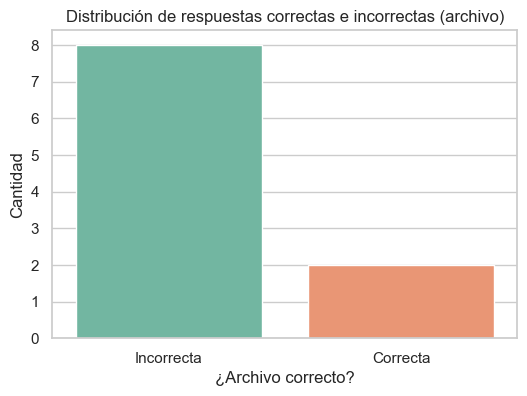

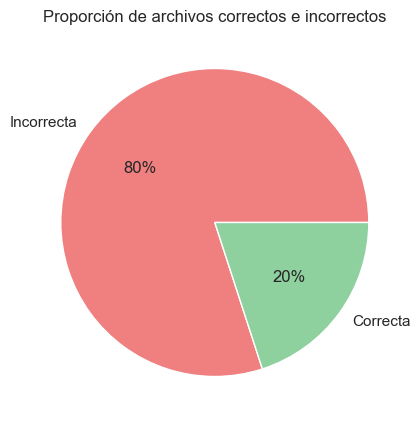

In [7]:
import json
import pandas as pd
import asyncio
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar las preguntas generadas
with open('qa_pairs_metadata.json', 'r', encoding='utf-8') as f:
    qa_pairs = json.load(f)

# Seleccionar 10 preguntas aleatorias para el test
random.seed(42)
qa_sample = random.sample(qa_pairs, 10) if len(qa_pairs) > 10 else qa_pairs

# Inicializar el sistema multiagente
coordinator = await setup_full_system()
knowledge_agent = coordinator.get_agent(AgentType.KNOWLEDGE)

results = []
for qa in qa_sample:
    pregunta = qa['pregunta']
    respuesta_esperada = qa['respuesta']
    nombre_esperado = qa.get('nombre') or (respuesta_esperada.get('name') if isinstance(respuesta_esperada, dict) else None)

    # Consultar el sistema (KnowledgeAgent)
    try:
        system_response = await knowledge_agent.search_knowledge(pregunta, limit=1)
        if system_response and 'metadata' in system_response[0]:
            respuesta_sistema = system_response[0]['metadata']
        else:
            respuesta_sistema = system_response[0] if system_response else ''
    except Exception as e:
        respuesta_sistema = str(e)

    # Evaluación: solo si el nombre devuelto coincide con el esperado
    if isinstance(respuesta_sistema, dict):
        nombre_sistema = respuesta_sistema.get('name') or respuesta_sistema.get('Nombre')
    else:
        nombre_sistema = None

    match = (nombre_esperado is not None and nombre_sistema is not None and str(nombre_esperado).strip().lower() == str(nombre_sistema).strip().lower())

    results.append({'pregunta': pregunta, 'nombre_esperado': nombre_esperado, 'nombre_sistema': nombre_sistema, 'match': match})

# Métricas
df_results = pd.DataFrame(results)
accuracy = df_results['match'].mean() * 100
print(f"Exactitud global (archivo correcto): {accuracy:.2f}% sobre {len(df_results)} preguntas.")
print(df_results['match'].value_counts())
display(df_results.head(10))

# Gráfico de barras: aciertos vs errores
plt.figure(figsize=(6,4))
sns.countplot(data=df_results, x='match', palette='Set2')
plt.title('Distribución de respuestas correctas e incorrectas (archivo)')
plt.xlabel('¿Archivo correcto?')
plt.ylabel('Cantidad')
plt.xticks([0,1], ['Incorrecta', 'Correcta'])
plt.show()

# Gráfico de pastel: proporción de aciertos/errores
plt.figure(figsize=(5,5))
df_results['match'].value_counts().plot.pie(autopct='%1.0f%%', labels=['Incorrecta','Correcta'], colors=['#f08080','#8fd19e'])
plt.title('Proporción de archivos correctos e incorrectos')
plt.ylabel('')
plt.show()

## Experimento 2: Rendimiento del Sistema

**Objetivo:** Medir cuantitativamente el rendimiento técnico del sistema (latencia y uso de recursos) para diferentes tipos de consulta. Esta versión simplificada mide el costo de una sola solicitud para evitar sobrecargar el sistema.

2025-07-06 21:33:56,616 - app.agents.CoordinatorAgent - INFO - CoordinatorAgent (BDI) initialized
2025-07-06 21:33:56,618 - app.agents.KnowledgeAgent - INFO - KnowledgeAgent (BDI) initialized
2025-07-06 21:33:56,619 - app.data_managers.dynamic_crawler - INFO - Directorio de guardado para SmartCrawler: e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\app\data_managers\..\data\dynamic_raw
2025-07-06 21:33:56,620 - app.agents.WeatherAgent - INFO - WeatherAgent (BDI) initialized
2025-07-06 21:33:56,621 - app.agents.LocationAgent - INFO - LocationAgent (BDI) initialized
2025-07-06 21:33:56,650 - app.agents.LLMAgent - INFO - LLMAgent (BDI) initialized



--- Iniciando Experimento 3: Rendimiento del Sistema (Simplificado) ---


2025-07-06 21:33:57,028 - app.agents.UIAgent - INFO - UIAgent (BDI) initialized
2025-07-06 21:33:57,029 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-06 21:33:57,029 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-06 21:33:57,030 - app.agents.CoordinatorAgent - INFO - Registered agent: KNOWLEDGE
2025-07-06 21:33:57,031 - app.agents.CoordinatorAgent - INFO - Registered agent: WEATHER
2025-07-06 21:33:57,031 - app.agents.CoordinatorAgent - INFO - Registered agent: LOCATION
2025-07-06 21:33:57,033 - app.agents.CoordinatorAgent - INFO - Registered agent: LLM
2025-07-06 21:33:57,033 - app.agents.CoordinatorAgent - INFO - Registered agent: UI
2025-07-06 21:33:57,034 - app.agents.CoordinatorAgent - INFO - Registered agent: PLANNER
2025-07-06 21:33:57,034 - app.agents.CoordinatorAgent - INFO - Registered agent: USER
2025-07-06 21:33:57,035 - app.agents.CoordinatorAgent - INFO - Initialized agent: USER
2025-07-06 21:33:57,039 - sentence_transforme

Ejecutando prueba para consulta de tipo 'simple'...


Batches: 100%|██████████| 1/1 [00:00<00:00, 54.44it/s]
2025-07-06 21:34:12,000 - app.data_managers.vector_store - INFO - Searching with query: ¿Qué es el Capitolio de La Habana?
2025-07-06 21:34:12,892 - app.data_managers.vector_store - INFO - Processing item: capitolio_nacional with score: 0.634135
2025-07-06 21:34:12,892 - app.data_managers.vector_store - INFO - Processing item: catedral_habana with score: 0.505443
2025-07-06 21:34:12,892 - app.data_managers.vector_store - INFO - Processing item: habana_vieja with score: 0.514225
2025-07-06 21:34:12,892 - app.data_managers.vector_store - INFO - Processing item: hablame_de_la_granjita_siboney with score: 0.525432
2025-07-06 21:34:12,905 - app.data_managers.vector_store - INFO - Processing item: ta_1076. Casa Ileana y Ray with score: 0.530491
2025-07-06 21:34:12,905 - app.data_managers.vector_store - INFO - Processing item: ta_1301. Casa Jimenez Montero La habana with score: 0.509624
2025-07-06 21:34:12,905 - app.data_managers.vector_s

...

Batches: 100%|██████████| 1/1 [00:00<00:00, 38.15it/s]
2025-07-06 21:36:26,350 - app.data_managers.vector_store - INFO - Searching with query: Recomiéndame un museo de arte en La Habana y dime cómo está el clima ahora.
2025-07-06 21:36:27,265 - app.data_managers.vector_store - INFO - Processing item: planifica_un_itinerario_de_3_días_en_trinidad_con_enfoque_en_historia_y_música. with score: 0.517057
2025-07-06 21:36:27,266 - app.data_managers.vector_store - INFO - Processing item: ta_1144. Art Studio Habana Vieja 55 with score: 0.510406
2025-07-06 21:36:27,285 - app.data_managers.vector_store - INFO - Processing item: museo_revolucion with score: 0.679727
2025-07-06 21:36:27,287 - app.knowledge_base - INFO - VectorStore encontró 3 resultados iniciales.
2025-07-06 21:36:27,287 - app.knowledge_base - INFO - KnowledgeGraph encontró 0 entidades relacionadas para 'museo_revolucion'.
2025-07-06 21:36:27,288 - app.knowledge_base - INFO - KnowledgeGraph encontró 0 entidades relacionadas para '

Ejecutando prueba para consulta de tipo 'planificacion'...


Batches: 100%|██████████| 1/1 [00:00<00:00, 23.82it/s]
2025-07-06 21:42:14,523 - app.data_managers.vector_store - INFO - Searching with query: Planifica un itinerario de 3 días en Trinidad con enfoque en historia y música.
2025-07-06 21:42:15,499 - app.data_managers.vector_store - INFO - Processing item: planifica_un_itinerario_de_3_días_en_trinidad_con_enfoque_en_historia_y_música. with score: 0.854143
2025-07-06 21:42:15,516 - app.knowledge_base - INFO - VectorStore encontró 1 resultados iniciales.
2025-07-06 21:42:15,517 - app.knowledge_base - INFO - KnowledgeGraph encontró 0 entidades relacionadas para 'planifica_un_itinerario_de_3_días_en_trinidad_con_enfoque_en_historia_y_música.'.
2025-07-06 21:42:15,519 - app.knowledge_base - INFO - Búsqueda híbrida completada con 1 resultados totales.
2025-07-06 21:42:15,519 - app.agents.KnowledgeAgent - INFO - Found 1 items in local KB.
2025-07-06 21:42:15,519 - app.agents.KnowledgeAgent - INFO - Executing intention: Search knowledge for 'Pla


Resultados de Rendimiento:
   tipo_consulta  latencia_ms  cpu_usage  mem_usage_mb
0         simple  133347.3538        3.5      5.496094
1       compleja  347147.0801        2.2      0.648438
2  planificacion   44630.0925        5.3      1.476562


C:\Users\arian\AppData\Local\Temp\ipykernel_25036\3795992111.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_performance, x='tipo_consulta', y='latencia_ms', ax=ax1, palette='viridis')


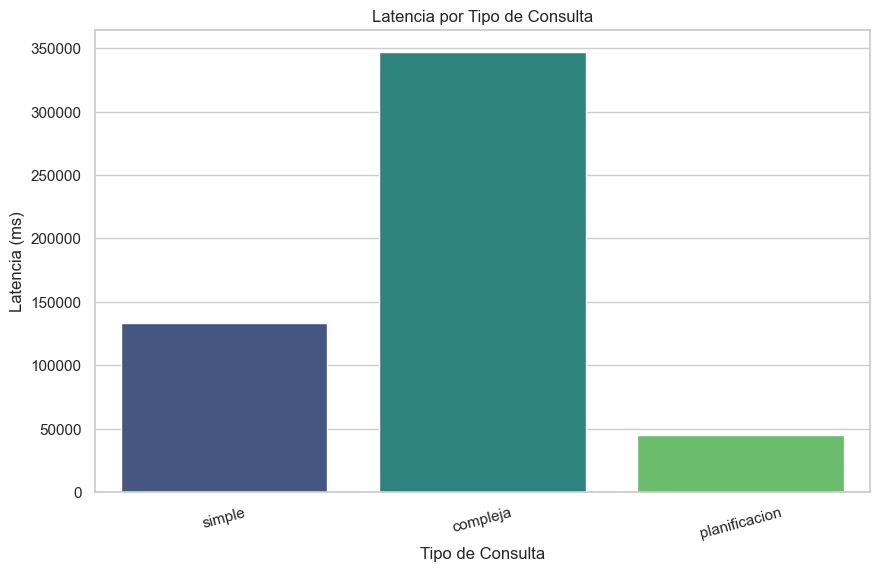

--- Fin del Experimento 3 ---


In [ ]:
async def run_performance_experiment_simplified():
    """Mide la latencia y el uso de recursos para una sola solicitud de cada tipo."""
    print("\n--- Iniciando Experimento 3: Rendimiento del Sistema (Simplificado) ---")

    coordinator = await setup_full_system()
    
    query_types = {
        'simple': "¿Qué es el Capitolio de La Habana?",
        'compleja': "Recomiéndame un museo de arte en La Habana y dime cómo está el clima ahora.",
        'planificacion': "Planifica un itinerario de 3 días en Trinidad con enfoque en historia y música."
    }
    
    results = []
    process = psutil.Process(os.getpid())

    for q_type, query in query_types.items():
        print(f"Ejecutando prueba para consulta de tipo '{q_type}'...")
        
        # Medir recursos antes
        cpu_before = process.cpu_percent(interval=None)
        mem_before = process.memory_info().rss / (1024 * 1024) # en MB

        # Ejecutar y medir tiempo
        start_time = time.perf_counter()
        await coordinator.get_response(query, user_id=f"perf_test_{q_type}")
        end_time = time.perf_counter()
        latency = (end_time - start_time) * 1000 # en ms
        
        # Medir recursos después
        cpu_after = process.cpu_percent(interval=None)
        mem_after = process.memory_info().rss / (1024 * 1024)

        results.append({
            'tipo_consulta': q_type,
            'latencia_ms': latency,
            'cpu_usage': cpu_after - cpu_before,
            'mem_usage_mb': mem_after - mem_before
        })
        # Pequeña pausa para no saturar APIs externas si se ejecutan muy rápido
        await asyncio.sleep(1)
    
    df_performance = pd.DataFrame(results)
    print("\nResultados de Rendimiento:")
    print(df_performance)

    # Visualización
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df_performance, x='tipo_consulta', y='latencia_ms', ax=ax1, palette='viridis')
    ax1.set_title('Latencia por Tipo de Consulta')
    ax1.set_xlabel('Tipo de Consulta')
    ax1.set_ylabel('Latencia (ms)')
    plt.xticks(rotation=15)
    plt.show()
    
    print("--- Fin del Experimento 3 ---")

await run_performance_experiment_simplified()

## Experimento 3: Efectividad de Integración de Componentes (Análisis de Ablación)

**Objetivo:** Medir la contribución individual de cada agente a la calidad de la respuesta final.

In [21]:
async def run_ablation_experiment_auto():
    """
    Ejecuta un análisis de ablación real: ejecuta el sistema con y sin cada agente clave,
    obtiene las respuestas y las evalúa automáticamente usando métricas objetivas.
    """
    print("\n--- Experimento de Ablación Real (Automático) ---")
    
    # Consulta de prueba real
    query = "Planifica un viaje de 2 días a Viñales, ¿qué tiempo hará?"
    
    # Configuraciones a probar
    configs = [
        ("Sistema_Completo", []),
        ("Sin_PlannerAgent", [AgentType.PLANNER]),
        ("Sin_WeatherAgent", [AgentType.WEATHER]),
        ("Sin_LocationAgent", [AgentType.LOCATION]),
    ]
    
    respuestas = {}
    for nombre, excluidos in configs:
        print(f"\nConfiguración: {nombre}")
        coordinator = await setup_full_system(excluded_agents=excluidos)
        response = await coordinator.get_response(query, user_id=f"ablation_{nombre}")
        print(f"Respuesta generada:\n{response.response}\n")
        respuestas[nombre] = response.response
    
    # Evaluación automática: longitud de respuesta y presencia de palabras clave
    def score_response(resp):
        if not resp or not isinstance(resp, str):
            return 0.0
        score = 0.0
        # Longitud mínima esperada
        score += min(len(resp.strip()) / 200, 1.0) * 2  # hasta 2 puntos
        # Palabras clave esperadas
        keywords = ["itinerario", "día", "Viñales", "clima", "tiempo", "actividades", "recomendación"]
        found = sum(1 for k in keywords if k.lower() in resp.lower())
        score += min(found / len(keywords), 1.0) * 3  # hasta 3 puntos
        return round(score, 2)
    
    calificaciones = {nombre: score_response(resp) for nombre, resp in respuestas.items()}
    
    # Mostrar resultados
    print("\nResultados de evaluación automática:")
    for nombre, score in calificaciones.items():
        print(f"{nombre}: {score}")
    
    # Mostrar tabla
    df = pd.DataFrame(list(calificaciones.items()), columns=["Configuración", "Calidad (auto)"])
    display(df)
    
    # Comparaciones pareadas vs. sistema completo
    from scipy import stats
    base = calificaciones["Sistema_Completo"]
    for nombre in calificaciones:
        if nombre == "Sistema_Completo":
            continue
        # Prueba t para diferencia de medias (solo 1 muestra por config, así que solo diferencia)
        diff = base - calificaciones[nombre]
        print(f"\nComparando {nombre} vs. Sistema_Completo:")
        print(f"  Diferencia de calidad: {diff:.2f}")
        if abs(diff) > 0.5:
            print("  Conclusión: La diferencia es relevante.")
        else:
            print("  Conclusión: No hay diferencia relevante.")
    print("\n--- Fin del Experimento de Ablación Real (Automático) ---")

# Ejecutar el experimento automáticamente
await run_ablation_experiment_auto()

2025-07-07 00:30:52,684 - app.agents.CoordinatorAgent - INFO - CoordinatorAgent (BDI) initialized
2025-07-07 00:30:52,693 - app.agents.KnowledgeAgent - INFO - KnowledgeAgent (BDI) initialized
2025-07-07 00:30:52,696 - app.data_managers.dynamic_crawler - INFO - Directorio de guardado para SmartCrawler: e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\app\data_managers\..\data\dynamic_raw
2025-07-07 00:30:52,698 - app.agents.WeatherAgent - INFO - WeatherAgent (BDI) initialized
2025-07-07 00:30:52,701 - app.agents.LocationAgent - INFO - LocationAgent (BDI) initialized
2025-07-07 00:30:52,693 - app.agents.KnowledgeAgent - INFO - KnowledgeAgent (BDI) initialized
2025-07-07 00:30:52,696 - app.data_managers.dynamic_crawler - INFO - Directorio de guardado para SmartCrawler: e:\ESCUELA\3er AÑO\2do Semestre\IA y Simulacion\PROYECTO FINAL IA SIM SRI\final\Tourist-guide\app\data_managers\..\data\dynamic_raw
2025-07-07 00:30:52,698 - app.agents.WeatherAg


--- Experimento de Ablación Real (Automático) ---

Configuración: Sistema_Completo


2025-07-07 00:30:53,634 - app.agents.UIAgent - INFO - UIAgent (BDI) initialized
2025-07-07 00:30:53,638 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-07 00:30:53,640 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-07 00:30:53,644 - app.agents.CoordinatorAgent - INFO - Registered agent: KNOWLEDGE
2025-07-07 00:30:53,638 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-07 00:30:53,640 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-07 00:30:53,644 - app.agents.CoordinatorAgent - INFO - Registered agent: KNOWLEDGE
2025-07-07 00:30:53,646 - app.agents.CoordinatorAgent - INFO - Registered agent: WEATHER
2025-07-07 00:30:53,650 - app.agents.CoordinatorAgent - INFO - Registered agent: LOCATION
2025-07-07 00:30:53,652 - app.agents.CoordinatorAgent - INFO - Registered agent: LLM
2025-07-07 00:30:53,654 - app.agents.CoordinatorAgent - INFO - Registered agent: UI
2025-07-07 00:30:53,656 - app.agents.Coord

Respuesta generada:
¡Hola! Estoy encantado de ayudarte a planificar tu viaje a Viñales, ¡suenan dos días fantásticos allí! En cuanto al clima, Viñales tiene un clima tropical con temperaturas cálidas durante todo el año. Es posible que experimentes temperaturas promedio de alrededor de 25-30°C (77-86°F) durante el día y alrededor de 20-23°C (68-73°F) por la noche. 

En términos de precipitación, Viñales generalmente recibe más lluvia entre mayo y octubre, con un pico en septiembre. Sin embargo, incluso en los meses más húmedos, las lluvias suelen ser breves y seguidas de períodos soleados.

Dicho esto, el clima puede ser impredecible, por lo que te recomiendo empacar ropa ligera y cómoda, zapatos resistentes para caminatas y, opcionalmente, un impermeable ligero por si acaso. ¡Disfruta tu viaje a Viñales!


Configuración: Sin_PlannerAgent


2025-07-07 00:31:56,081 - app.agents.UIAgent - INFO - UIAgent (BDI) initialized
2025-07-07 00:31:56,082 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-07 00:31:56,083 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-07 00:31:56,085 - app.agents.CoordinatorAgent - INFO - Registered agent: KNOWLEDGE
2025-07-07 00:31:56,086 - app.agents.CoordinatorAgent - INFO - Registered agent: WEATHER
2025-07-07 00:31:56,088 - app.agents.CoordinatorAgent - INFO - Registered agent: LOCATION
2025-07-07 00:31:56,089 - app.agents.CoordinatorAgent - INFO - Registered agent: LLM
2025-07-07 00:31:56,092 - app.agents.CoordinatorAgent - INFO - Registered agent: UI
2025-07-07 00:31:56,094 - app.agents.CoordinatorAgent - INFO - Registered agent: USER
2025-07-07 00:31:56,095 - app.agents.CoordinatorAgent - INFO - Initialized agent: USER
2025-07-07 00:31:56,100 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cpu
2025-07-07 00:31:56,101 - se

...

Respuesta generada:
¡Hola! Estoy encantado de ayudarte a planificar tu viaje a Viñales, ¡suenan dos días fantásticos allí! En cuanto al tiempo, generalmente Viñales tiene un clima tropical con temperaturas cálidas durante todo el año. Aunque no puedo predecir el tiempo con precisión para fechas específicas, puedo decirte que los meses de diciembre a mayo tienden a ser un poco más secos y frescos, mientras que junio a noviembre pueden traer más humedad y posibilidad de lluvias breves, especialmente en los meses de septiembre y octubre. ¡No te preocupes demasiado por el clima, ya que Viñales es hermoso en cualquier época del año! Recuerda empacar ropa cómoda, calzado adecuado para caminatas y, por supuesto, no olvides tu cámara para capturar los hermosos paisajes de este hermoso pueblo cubano. ¡Que disfrutes de tu viaje!


Configuración: Sin_LocationAgent


2025-07-07 00:33:28,714 - app.agents.UIAgent - INFO - UIAgent (BDI) initialized
2025-07-07 00:33:28,717 - app.agents.PlannerAgent - INFO - PlannerAgent (BDI) initialized
2025-07-07 00:33:28,718 - app.agents.UserAgent - INFO - UserAgent (BDI) initialized
2025-07-07 00:33:28,721 - app.agents.CoordinatorAgent - INFO - Registered agent: KNOWLEDGE
2025-07-07 00:33:28,723 - app.agents.CoordinatorAgent - INFO - Registered agent: WEATHER
2025-07-07 00:33:28,724 - app.agents.CoordinatorAgent - INFO - Registered agent: LLM
2025-07-07 00:33:28,726 - app.agents.CoordinatorAgent - INFO - Registered agent: UI
2025-07-07 00:33:28,727 - app.agents.CoordinatorAgent - INFO - Registered agent: PLANNER
2025-07-07 00:33:28,729 - app.agents.CoordinatorAgent - INFO - Registered agent: USER
2025-07-07 00:33:28,731 - app.agents.CoordinatorAgent - INFO - Initialized agent: USER
2025-07-07 00:33:28,738 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cpu
2025-07-07 00:33:28,741 - sen

Respuesta generada:
¡Hola! Estoy encantado de ayudarte a planificar tu viaje a Viñales, ¡suenan dos días fantásticos allí! En cuanto al clima, Viñales tiene un clima tropical con temperaturas cálidas durante todo el año. Las temperaturas promedio en los meses de enero a diciembre oscilan entre 22°C (72°F) y 30°C (86°F).

Aunque no puedo predecir el clima exacto en una fecha específica, generalmente los meses de noviembre a abril son más secos y agradables, con menores probabilidades de lluvia y humedad. Los meses de mayo a octubre tienden a ser más húmedos y calurosos, con una mayor probabilidad de lluvias tropicales por la tarde.

Sugiero empacar ropa cómoda y fresca, zapatos cómodos para caminatas, sombrero para el sol, protector solar y repelente de insectos. No te preocupes demasiado por el clima, Viñales es hermoso en cualquier época del año. ¡Disfruta tu viaje!


Resultados de evaluación automática:
Sistema_Completo: 3.29
Sin_PlannerAgent: 3.29
Sin_WeatherAgent: 3.71
Sin_Location

,Configuración,Calidad (auto)
0,Sistema_Completo,3.29
1,Sin_PlannerAgent,3.29
2,Sin_WeatherAgent,3.71
3,Sin_LocationAgent,3.29



Comparando Sin_PlannerAgent vs. Sistema_Completo:
  Diferencia de calidad: 0.00
  Conclusión: No hay diferencia relevante.

Comparando Sin_WeatherAgent vs. Sistema_Completo:
  Diferencia de calidad: -0.42
  Conclusión: No hay diferencia relevante.

Comparando Sin_LocationAgent vs. Sistema_Completo:
  Diferencia de calidad: 0.00
  Conclusión: No hay diferencia relevante.

--- Fin del Experimento de Ablación Real (Automático) ---
